In [18]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [19]:
from fem import (
    # Gmsh tools
    GMSHtools,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_gmsh_mesh,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [20]:
globalParameters['nDoF'] = 3
globalParameters['nDIM'] = 3

In [21]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'example'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [22]:
# # Material
# Steel=Material( name='Steel',
#                 E=2000,
#                 nu=0.30,
#                 rho=1.25*tf/m**3*0)

# # Sections
# F1=Membrane(    name='F1',
#                 thickness=15,
#                 material=Steel)

# # Dictionaries
# section_dictionary={274:F1,
#                         }

# restrain_dictionary={275:['r', 'r' , 'r'] , 
#                      277: ['f' , 'f' , 'r']}

load_dictionary = {
                257:   {'value': 4, 'direction': '-y'},     
}

In [23]:
# Read mesh
mesh = GMSHtools(output_file)

system_nDof = mesh.system_nDof
node_map = mesh.node_map


Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/examples_3D/vertical_load_animation/example.msh'...
Info    : 107 entities
Info    : 1145 nodes
Info    : 3248 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/examples_3D/vertical_load_animation/example.msh'
  MESH SUMMARY

  === NODES ===  (1145 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         2.0000        -0.2500         0.0000
       2         2.5000        -0.2500         0.0000
       3         0.2500        -0.2500         2.4875
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (2 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      53      2   'support'
      54      3   'solid'
--------------------------------

In [24]:
# remove floating nodes
connected_nodes = set()
for group in mesh.elements.values():
    for conn in group['connectivity']:
        connected_nodes.update(conn)

floating = set(mesh.nodes.keys()) - connected_nodes
for tag in floating:
    del mesh.nodes[tag]
print(f"Removed {len(floating)} floating nodes: {floating}")

# recalculate node_map and system_nDof
from fem.utils.functions import plan
mesh.node_map, mesh.system_nDof = plan(mesh)

node_map    = mesh.node_map
system_nDof = mesh.system_nDof

Removed 0 floating nodes: set()


In [25]:
# # Load vector
# F_nodal = build_load_vector(mesh, 
#                             load_dictionary)

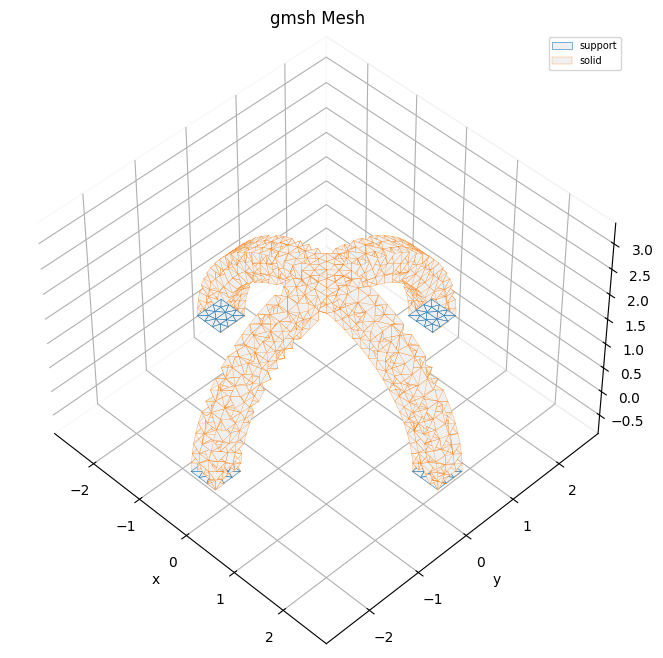

In [26]:
# %matplotlib widget

plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
               view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

## Opensees

In [27]:
import openseespy.opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 3, '-ndf', 3)

In [28]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y , z)

In [29]:
# Boundary conditions
fixed_nodes = set()
for tag in mesh.physical_groups['support'].nodes:
    if tag not in fixed_nodes:
        fixed_nodes.add(tag)
        # ops.fix(tag, 1, 1, 1, 1, 1, 1)
        ops.fix(tag, 1, 1, 1)

In [30]:
# Material
E = 210e9      
nu = 0.33
rho=7300
g=9.81
ops.nDMaterial('ElasticIsotropic', 1, E, nu, rho)


In [31]:
group = mesh.physical_groups['solid'].elements
for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
    n1, n2, n3, n4 = conn
    ops.element('FourNodeTetrahedron', elem_tag, n1, n2, n3, n4, 1)

In [32]:
# opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [33]:
# calcular volumen de cada tetrahedro y repartir peso a nodos
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

nodal_weight = {}
for conn in group['connectivity']:
    n1, n2, n3, n4 = conn
    pts = [np.array(mesh.nodes[n][:3]) for n in [n1, n2, n3, n4]]
    vol = abs(np.dot(pts[1]-pts[0], np.cross(pts[2]-pts[0], pts[3]-pts[0]))) / 6.0
    weight = rho * g * vol / 4.0
    for tag in [n1, n2, n3, n4]:
        nodal_weight[tag] = nodal_weight.get(tag, 0.0) + weight

for tag, w in nodal_weight.items():
    ops.load(tag, 0., 0., -w)

In [34]:
node_tags = np.array(list(mesh.nodes.keys()))
n_nodes   = len(mesh.nodes)

# Eigenanalysis
n_modes = 6
eigenvalues = ops.eigen(n_modes)
omega = np.sqrt(np.array(eigenvalues))
freq  = omega / (2 * np.pi)
period = 1 / freq

print(f"{'Mode':>6} {'Freq [Hz]':>12} {'Period [s]':>12}")
for i in range(n_modes):
    print(f"{i+1:>6} {freq[i]:>12.4f} {period[i]:>12.4f}")



  Mode    Freq [Hz]   Period [s]
     1     112.3929       0.0089
     2     112.8145       0.0089
     3     146.3697       0.0068
     4     238.9249       0.0042
     5     243.3332       0.0041
     6     256.1188       0.0039


In [37]:
mode    = 3
n_steps = 30
factor  = 50

mode_3d = np.zeros((n_nodes, 3))
for i, tag in enumerate(mesh.nodes.keys()):
    mode_3d[i, 0] = ops.nodeEigenvector(tag, mode, 1)
    mode_3d[i, 1] = ops.nodeEigenvector(tag, mode, 2)
    mode_3d[i, 2] = ops.nodeEigenvector(tag, mode, 3)

gmsh.initialize()
gmsh.open(output_file)

view_mode = gmsh.view.add(f"Mode {mode} — T={period[mode-1]:.4f}s")

for step in range(n_steps):
    scale = np.cos(step / n_steps * 2 * np.pi)
    gmsh.view.addHomogeneousModelData(
        tag           = view_mode,
        step          = step,
        time          = float(step),
        modelName     = gmsh.model.getCurrent(),
        dataType      = "NodeData",
        numComponents = -1,
        tags          = node_tags,
        data          = (mode_3d * scale).reshape(-1)
    )

gmsh.view.option.setNumber(view_mode, "VectorType",         5)
gmsh.view.option.setNumber(view_mode, "DisplacementFactor", factor)
gmsh.fltk.run()
gmsh.finalize()

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/examples_3D/vertical_load_animation/example.msh'...
Info    : 107 entities
Info    : 1145 nodes
Info    : 3248 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/examples_3D/vertical_load_animation/example.msh'
-------------------------------------------------------
Version       : 4.15.2
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20260324
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjlo